In [8]:
import os
import sys
from pathlib import Path

# analysis/ --> MeetScribe/
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project Root:", PROJECT_ROOT)
print("Analysis Folder:", Path.cwd())

# Verify that ml_mom exists
print("ml_mom exists:", (PROJECT_ROOT / "ml_mom").exists())

Project Root: c:\Users\Lenovo\Desktop\meetscribe
Analysis Folder: c:\Users\Lenovo\Desktop\meetscribe\analysis
ml_mom exists: True


In [9]:
# ============================================================
# Import required libraries
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from ml_mom.embeddings import EmbeddingService
from ml_mom.feature_extraction import SentenceFeature

In [10]:
# ============================================================
# Load training dataset
#
# NOTE:
# If this path is different in your project,
# update it accordingly.
# ============================================================

dataset_path = PROJECT_ROOT / "datasets" / "processed" / "master_dataset.csv"

df = pd.read_csv(dataset_path)

print(df.shape)

df.head()

(241, 7)


,sentence_id,turn_id,speaker,timestamp,sentence,selected_label,notes
0,1,1,Date,NaN,24 July 2026 Participants Aarav (Project Manag...,Information,NaN
1,2,2,Aarav,32405.0,Good morning everyone.,Information,NaN
2,3,3,Priya,32412.0,Morning.,Information,NaN
3,4,4,Rahul,32418.0,Good morning.,Information,NaN
4,5,5,Aarav,32425.0,Today's goal is to finalize the feature list f...,Information,NaN


In [11]:
# ============================================================
# Display available columns
# ============================================================

print(df.columns.tolist())

['sentence_id', 'turn_id', 'speaker', 'timestamp', 'sentence', 'selected_label', 'notes']


In [14]:
# ============================================================
# Convert dataset into transcript format
#
# We are creating a transcript exactly like the website
# receives before generating embeddings.
# ============================================================

transcript = ""

for _, row in df.iterrows():

    speaker = row["speaker"]

    sentence = row["sentence"]

    transcript += f"{speaker}: {sentence}\n"

print(transcript[:500])# ============================================================
# Convert dataset into transcript format
#
# We are creating a transcript exactly like the website
# receives before generating embeddings.
# ============================================================

transcript = ""

for _, row in df.iterrows():

    speaker = row["speaker"]

    sentence = row["sentence"]

    transcript += f"{speaker}: {sentence}\n"

print(transcript[:500])

Date: 24 July 2026 Participants Aarav (Project Manager) Neha (ML Engineer) Rahul (Backend Developer) Priya (Frontend Developer) Ananya (QA Engineer)
Aarav: Good morning everyone.
Priya: Morning.
Rahul: Good morning.
Aarav: Today's goal is to finalize the feature list for Sprint 4.
Neha: The meeting summarization model has reached 91% evaluation accuracy.
Rahul: The export APIs are also ready.
Aarav: Are there any blockers before release?
Priya: The PDF export layout still needs some polishing.
A
Date: 24 July 2026 Participants Aarav (Project Manager) Neha (ML Engineer) Rahul (Backend Developer) Priya (Frontend Developer) Ananya (QA Engineer)
Aarav: Good morning everyone.
Priya: Morning.
Rahul: Good morning.
Aarav: Today's goal is to finalize the feature list for Sprint 4.
Neha: The meeting summarization model has reached 91% evaluation accuracy.
Rahul: The export APIs are also ready.
Aarav: Are there any blockers before release?
Priya: The PDF export layout still needs some polishing.


In [15]:
# ============================================================
# Run the SAME preprocessing pipeline used by the website
#
# Transcript
#     ↓
# Parser
#     ↓
# Preprocessing
#     ↓
# Feature Extraction
# ============================================================

from ml_mom.transcript_parser import parse_transcript
from ml_mom.preprocessing import preprocess_transcript
from ml_mom.feature_extraction import extract_sentence_features

parsed = parse_transcript(transcript)

print("Parsed Turns :", len(parsed.turns))

cleaned_turns = preprocess_transcript(parsed.turns)

print("Cleaned Turns :", len(cleaned_turns))

sentence_features = extract_sentence_features(cleaned_turns)

print("Sentence Features :", len(sentence_features))

Parsed Turns : 240
Cleaned Turns : 240
Sentence Features : 240


In [16]:
# ============================================================
# Generate MiniLM Embeddings
# ============================================================

from ml_mom.embeddings import EmbeddingService

embedding_service = EmbeddingService()

embedding_result = embedding_service.generate_embeddings(
    sentence_features
)

print("Embeddings :", len(embedding_result.embeddings))

c:\Users\Lenovo\Desktop\meetscribe\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1969.35it/s]


Embeddings : 240


In [17]:
# ============================================================
# Convert embeddings into NumPy array
# ============================================================

import numpy as np

embeddings = np.array(
    [
        embedding.embedding_vector
        for embedding in embedding_result.embeddings
    ]
)

print(embeddings.shape)

(240, 384)


In [18]:
# ============================================================
# PCA Visualization
# ============================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

points = pca.fit_transform(embeddings)

print(points.shape)

(240, 2)


In [20]:
print("Dataset rows :", len(df))
print("Sentence Features :", len(sentence_features))
print("Embeddings :", len(embeddings))

Dataset rows : 241
Sentence Features : 240
Embeddings : 240


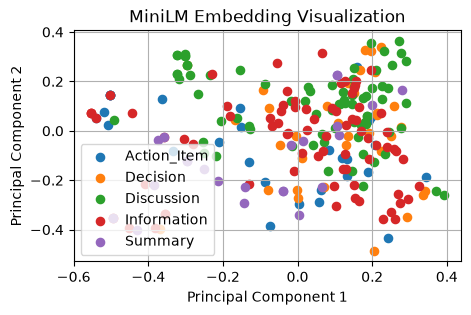

In [25]:
# ============================================================
# Plot only the rows that successfully reached embeddings
# ============================================================

import matplotlib.pyplot as plt

# Keep only labels for rows that were actually embedded
plot_labels = df.iloc[:len(points)]["selected_label"].values

plt.figure(figsize=(5,3))

for label in sorted(set(plot_labels)):

    mask = plot_labels == label

    plt.scatter(
        points[mask,0],
        points[mask,1],
        s=35,
        label=label
    )

plt.title("MiniLM Embedding Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.legend()

plt.show()